In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fruit Dataset.zip to Fruit Dataset.zip


In [ ]:
import zipfile
with zipfile.ZipFile("Fruit Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/Fruit Dataset")

In [ ]:
import os
for item in os.listdir("/content/Fruit Dataset/archive (2)"):
    print(item)

Good Quality_Fruits
Bad Quality_Fruits
Mixed Quality_Fruits


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks as kcallbacks
from tensorflow.keras.applications import EfficientNetV2B0, ResNet50V2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as ef_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
import warnings
warnings.filterwarnings('ignore')

print("GPU available:", tf.config.list_physical_devices('GPU'))
print("="*50)
print("Fruit Quality Detection - Ensemble Learning Pipeline")
print("="*50)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fruit Quality Detection - Ensemble Learning Pipeline


In [ ]:
DATA_DIR = "/content/Fruit Dataset/archive (2)"   # <-- change to match your folder

CLASS_NAMES = ['Bad Quality_Fruits', 'Good Quality_Fruits', 'Mixed Quality_Fruits']
CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 10
RANDOM_STATE = 42

In [ ]:
all_image_paths = []
all_labels = []
for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(class_dir, img_file))
                all_labels.append(CLASS_MAP[class_name])

print(f"Loaded {len(all_image_paths)} images.")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.3, random_state=RANDOM_STATE, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=RANDOM_STATE, stratify=temp_labels
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")

Loaded 2403 images.
Train: 1682  Val: 360  Test: 361


In [ ]:
def load_and_preprocess_image(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(paths, labels, batch_size=BATCH_SIZE, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(lambda x, y: load_and_preprocess_image(x, y, augment),
                          num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(train_paths, train_labels, augment=True)
val_ds = create_dataset(val_paths, val_labels, augment=False)
test_ds = create_dataset(test_paths, test_labels, augment=False)

In [ ]:
def build_efficientnet_model():
    base_model = EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = ef_preprocess(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

ef_model, ef_base = build_efficientnet_model()

ef_callbacks = [
    kcallbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    kcallbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    kcallbacks.ModelCheckpoint('best_ef_model.keras', save_best_only=True, monitor='val_accuracy')
]

print("Phase 1: Training classification head...")
history1 = ef_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE1, callbacks=ef_callbacks)

ef_base.trainable = True
for layer in ef_base.layers[:100]:
    layer.trainable = False

ef_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Phase 2: Fine-tuning...")
history2 = ef_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE2, callbacks=ef_callbacks)

ef_model = models.load_model('best_ef_model.keras')

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training classification head...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 775ms/step - accuracy: 0.8228 - loss: 0.4608 - val_accuracy: 0.9583 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9602 - loss: 0.1703 - val_accuracy: 0.9694 - val_loss: 0.1166 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9679 - loss: 0.1208 - val_accuracy: 0.9750 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9738 - loss: 0.1016 - val_accuracy: 0.9806 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9732 - loss: 0.0840 - val_accuracy: 0.9833 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.9768 - loss: 0.0809 - val_accuracy: 0.9917 - val_loss: 0.0520 - learning_rate: 0.0010


In [ ]:
def build_resnet_model():
    base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = resnet_preprocess(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

resnet_model, resnet_base = build_resnet_model()

resnet_callbacks = [
    kcallbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    kcallbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    kcallbacks.ModelCheckpoint('best_resnet_model.keras', save_best_only=True, monitor='val_accuracy')
]

print("Training ResNet50V2...")
resnet_history = resnet_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE1, callbacks=resnet_callbacks)

resnet_base.trainable = True
for layer in resnet_base.layers[:100]:
    layer.trainable = False

resnet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Fine-tuning ResNet50V2...")
resnet_history2 = resnet_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE2, callbacks=resnet_callbacks)

resnet_model = models.load_model('best_resnet_model.keras')

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training ResNet50V2...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.7812 - loss: 0.5452 - val_accuracy: 0.9444 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9501 - loss: 0.1469 - val_accuracy: 0.9722 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.9679 - loss: 0.1065 - val_accuracy: 0.9833 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9667 - loss: 0.0927 - val_accuracy: 0.9833 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9774 - loss: 0.0686 - val_accuracy: 0.9833 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.9816 - loss: 0.0595 - val_accuracy: 0.9833 - val_loss: 0.0485 - learning_rate: 0.0010
Epoch 7/15
53/53

In [ ]:
def extract_features(model, dataset):
    feature_extractor = models.Model(inputs=model.input, outputs=model.layers[-2].output)
    features, labels = [], []
    for images, lbls in dataset:
        feats = feature_extractor.predict(images, verbose=0)
        features.append(feats)
        labels.append(lbls.numpy())
    return np.vstack(features), np.hstack(labels)

print("Extracting EfficientNetV2 features...")
train_features_ef, train_labels_ef = extract_features(ef_model, train_ds)
val_features_ef, _ = extract_features(ef_model, val_ds)
test_features_ef, test_labels_ef = extract_features(ef_model, test_ds)

print("Extracting ResNet50V2 features...")
train_features_resnet, _ = extract_features(resnet_model, train_ds)
val_features_resnet, _ = extract_features(resnet_model, val_ds)
test_features_resnet, _ = extract_features(resnet_model, test_ds)

train_features = np.hstack([train_features_ef, train_features_resnet])
val_features = np.hstack([val_features_ef, val_features_resnet])
test_features = np.hstack([test_features_ef, test_features_resnet])

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)
test_features = scaler.transform(test_features)

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5,
                                   min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(train_features, train_labels_ef)

Extracting EfficientNetV2 features...
Extracting ResNet50V2 features...
Training Random Forest...


RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

EfficientNetV2 test accuracy: 0.9889
ResNet50V2 test accuracy: 0.9917
Random Forest test accuracy: 0.9751
Soft Voting ensemble accuracy: 0.9917

Classification Report:
                      precision    recall  f1-score   support

  Bad Quality_Fruits       0.99      0.99      0.99       171
 Good Quality_Fruits       0.99      0.99      0.99       173
Mixed Quality_Fruits       1.00      1.00      1.00        17

            accuracy                           0.99       361
           macro avg       0.99      0.99      0.99       361
        weighted avg       0.99      0.99      0.99       361



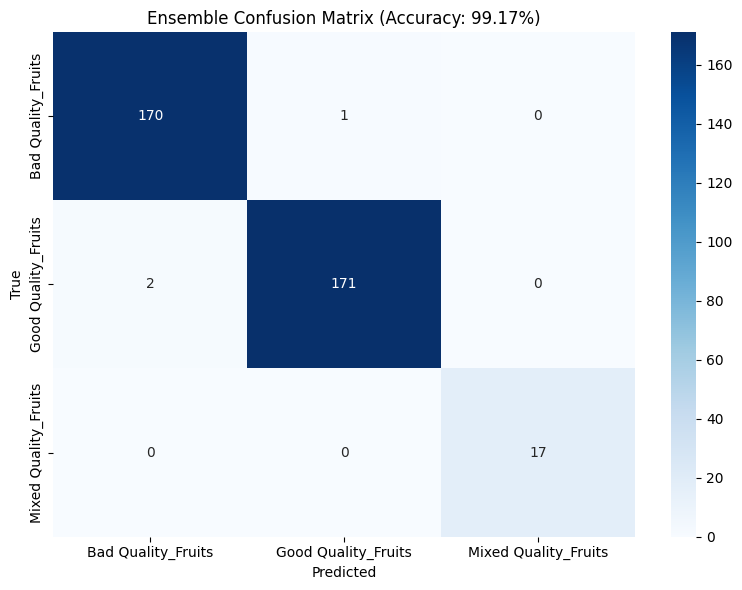

In [ ]:
ef_loss, ef_acc = ef_model.evaluate(test_ds, verbose=0)
print(f"EfficientNetV2 test accuracy: {ef_acc:.4f}")

resnet_loss, resnet_acc = resnet_model.evaluate(test_ds, verbose=0)
print(f"ResNet50V2 test accuracy: {resnet_acc:.4f}")

rf_pred = rf_model.predict(test_features)
rf_acc = accuracy_score(test_labels_ef, rf_pred)
print(f"Random Forest test accuracy: {rf_acc:.4f}")

ef_pred_proba = ef_model.predict(test_ds, verbose=0)
resnet_pred_proba = resnet_model.predict(test_ds, verbose=0)
rf_pred_proba = rf_model.predict_proba(test_features)

ensemble_pred_soft = np.argmax((ef_pred_proba + resnet_pred_proba + rf_pred_proba) / 3, axis=1)
ensemble_acc_soft = accuracy_score(test_labels_ef, ensemble_pred_soft)
print(f"Soft Voting ensemble accuracy: {ensemble_acc_soft:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels_ef, ensemble_pred_soft, target_names=CLASS_NAMES))

cm = confusion_matrix(test_labels_ef, ensemble_pred_soft)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Ensemble Confusion Matrix (Accuracy: {ensemble_acc_soft:.2%})')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
import joblib

# Save Random Forest and scaler (the .keras models are already saved by ModelCheckpoint)
joblib.dump(rf_model, 'rf_model.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')

# Mount Google Drive and copy everything there so it survives the session ending
from google.colab import drive
drive.mount('/content/drive')

import shutil
save_dir = '/content/drive/MyDrive/fruit_quality_model'
os.makedirs(save_dir, exist_ok=True)

for fname in ['best_ef_model.keras', 'best_resnet_model.keras', 'rf_model.joblib', 'feature_scaler.joblib', 'confusion_matrix.png']:
    shutil.copy(fname, save_dir)

print(f"All files saved to {save_dir}")

In [ ]:
def predict_fruit_quality(img_path):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image_batch = tf.expand_dims(image, axis=0)

    ef_proba = ef_model.predict(image_batch, verbose=0)
    resnet_proba = resnet_model.predict(image_batch, verbose=0)

    ef_extractor = models.Model(inputs=ef_model.input, outputs=ef_model.layers[-2].output)
    resnet_extractor = models.Model(inputs=resnet_model.input, outputs=resnet_model.layers[-2].output)
    ef_feat = ef_extractor.predict(image_batch, verbose=0)
    resnet_feat = resnet_extractor.predict(image_batch, verbose=0)
    combined_feat = np.hstack([ef_feat, resnet_feat])
    combined_feat = scaler.transform(combined_feat)
    rf_proba = rf_model.predict_proba(combined_feat)

    final_proba = (ef_proba + resnet_proba + rf_proba) / 3
    predicted_class = np.argmax(final_proba, axis=1)[0]
    confidence = final_proba[0][predicted_class]

    print(f"Predicted: {CLASS_NAMES[predicted_class]}")
    print(f"Confidence: {confidence:.2%}")
    print("\nAll class probabilities:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name}: {final_proba[0][i]:.2%}")

    return CLASS_NAMES[predicted_class], confidence

# Upload a single test image
from google.colab import files
uploaded = files.upload()

Saving IMG20200728130607.jpg to IMG20200728130607.jpg


In [ ]:
# Replace with the filename printed after upload
test_filename = list(uploaded.keys())[0]
predict_fruit_quality(test_filename)

Predicted: Mixed Quality_Fruits
Confidence: 91.81%

All class probabilities:
  Bad Quality_Fruits: 2.90%
  Good Quality_Fruits: 5.29%
  Mixed Quality_Fruits: 91.81%


('Mixed Quality_Fruits', np.float64(0.9181114662311695))